<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 16</span></h2>
<h1><span style="color: #1F77B4; font-size: 40px">Apprentissage par différence temporelle</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte et permet de régénérer les figures associées selon les conventions graphiques du livre. Il couvre TD(0), SARSA, Q-learning, SARSA espéré, double Q-learning, TD($\lambda$) et le réglage des principaux hyperparamètres. Le monde en grille du chapitre 15 y est redéfini afin que le carnet soit autonome, tandis qu'un second environnement, la marche au bord de la falaise, sert à confronter l'apprentissage sur politique et hors politique. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy` et `matplotlib`. Comme au chapitre 15, aucune bibliothèque d'apprentissage par renforcement n'est employée.  
**Données externes** : aucun fichier externe n'est nécessaire.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

PAQUETS = ('numpy', 'matplotlib')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT, BLEU, MAGENTA = '#482878', '#21918c', '#5ec962', '#3b528b', '#bf00bf'
BORD    = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b', MAGENTA: '#8a008a'}
PALETTE = [VIOLET, SARCELLE, VERT, BLEU, MAGENTA]

FLECHE = {'haut': '↑', 'bas': '↓', 'gauche': '←', 'droite': '→'}

python             3.12.13
numpy              2.5.1
matplotlib         3.11.0


<hr style='border-top:4px solid #1F77B4;'>

In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

In [3]:
def dessiner_grille(ax, env, valeurs=None, politique=None, titre='', taille=20):
    """Trace la grille, avec ses valeurs et ses flèches de politique."""
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

    murs = getattr(env, 'mur', set())
    falaise = getattr(env, 'falaise', set())
    n, m = env.n_lignes, env.n_colonnes
    compact = bool(falaise)
    haut = n + (0.55 if titre else 0.05)
    bas = -0.42 if compact else -0.05
    ax.set_xlim(-0.05, m + 0.05)
    ax.set_ylim(bas, haut)
    ax.set_aspect('equal')
    ax.set_axis_off()

    # Tailles adaptées à l'espace physique disponible dans chaque sous-figure.
    pos = ax.get_position()
    largeur, hauteur = ax.figure.get_size_inches()
    unite = 72 * min(largeur * pos.width / (m + 0.1),
                     hauteur * pos.height / (haut - bas))
    corps = min(14, 0.25 * unite)
    petit = min(12, 0.29 * unite)
    en_tete = min(14, 0.28 * unite)

    if titre:
        ax.add_patch(FancyBboxPatch(
            (0, n + 0.12), m, 0.38,
            boxstyle='round,pad=0,rounding_size=0.04',
            facecolor='#F0F1F3', edgecolor='none'))
        ax.add_patch(Rectangle((0, n + 0.12), m, 0.025, facecolor='#3B528B', edgecolor='none'))
        ax.text(m / 2, n + 0.31, titre, ha='center', va='center', fontsize=en_tete, color='#172033')

    for i in range(n):
        for j in range(m):
            s, y = (i, j), n - 1 - i
            fond, bord, texte = '#FFFFFF', '#BCC7D8', '#172033'
            if s == env.depart:
                fond, bord, texte = '#E8EFFA', '#3B528B', '#3B528B'
            if s in murs:
                fond, bord, texte = '#D7DBE1', '#9098A6', '#495464'
            elif s in falaise:
                fond, bord, texte = '#D5CBE4', '#414487', '#414487'
            elif s in env.terminaux:
                if env.terminaux[s] < 0:
                    fond, bord, texte = '#D5CBE4', '#414487', '#414487'
                else:
                    fond, bord, texte = '#DEF2E0', '#5EC962', '#315F34'
            ax.add_patch(FancyBboxPatch(
                (j + 0.032, y + 0.032), 0.936, 0.936,
                boxstyle='round,pad=0,rounding_size=0.065',
                facecolor=fond, edgecolor=bord, linewidth=0.9,
                hatch='///' if s in falaise else None))

            if s in murs:
                ax.text(j + 0.5, y + 0.5, 'Mur', ha='center',
                        va='center', fontsize=petit, color=texte)
            elif s in falaise:
                continue
            elif s in env.terminaux:
                if compact:
                    ax.text(j + 0.5, y + 0.5, 'B', ha='center',
                            va='center', fontsize=petit, color=texte)
                else:
                    recompense = env.terminaux[s]
                    ax.text(j + 0.5, y + 0.61, f'${recompense:+.0f}$',
                            ha='center', va='center', fontsize=corps + 2,
                            color=texte)
                    ax.text(j + 0.5, y + 0.26,
                            'Piège' if recompense < 0 else 'But',
                            ha='center', va='center', fontsize=petit,
                            color=texte)
            else:
                if valeurs is not None:
                    ax.text(j + 0.5, y + (0.72 if politique else 0.55),
                            f'${valeurs[s]:+.3f}$', ha='center', va='center',
                            fontsize=corps, color=texte)
                if politique is not None:
                    di, dj = env.PAS[politique[s]]
                    dx, dy = dj, -di
                    cy = y + (0.40 if valeurs is not None else
                              0.56 if s == env.depart else 0.5)
                    ax.add_patch(FancyArrowPatch(
                        (j + 0.5 - 0.20 * dx, cy - 0.20 * dy),
                        (j + 0.5 + 0.20 * dx, cy + 0.20 * dy),
                        arrowstyle='-|>', color='#3B528B',
                        linewidth=1.35, mutation_scale=min(taille, 0.34 * unite),
                        shrinkA=0, shrinkB=0))
                if s == env.depart:
                    ax.text(j + 0.5, y + (0.5 if compact and politique is None
                                         and valeurs is None else 0.15),
                            'D' if compact else 'départ', ha='center',
                            va='center', fontsize=petit, color=texte)

    if compact:
        from matplotlib.patches import Patch

        elements = [
            Patch(facecolor='#E8EFFA', edgecolor='#3B528B',
                  linewidth=0.9, label='D : départ'),
            Patch(facecolor='#DEF2E0', edgecolor='#5EC962',
                  linewidth=0.9, label='B : but'),
            Patch(facecolor='#D5CBE4', edgecolor='#414487',
                  linewidth=0.9, hatch='///', label='Falaise')
        ]

        ax.legend(handles=elements, loc='center', bbox_to_anchor=(m / 2, -0.23),
            bbox_transform=ax.transData, ncol=3, frameon=False,
            fontsize=min(9, 0.29 * unite), labelcolor='#495464',
            handlelength=1.1, handleheight=1.1, handletextpad=0.5,
            columnspacing=1.5, borderaxespad=0)


In [4]:
def lisser(x, fenetre=50):
    """Moyenne glissante, pour rendre lisibles les courbes de retour."""
    return np.convolve(x, np.ones(fenetre) / fenetre, mode='valid')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.1 : Le monde en grille et sa solution exacte</h3>

In [5]:
class MondeGrille:
    """Grille 3 x 4 du chapitre 15, redéfinie ici pour que le carnet soit autonome."""

    ACTIONS = ['haut', 'bas', 'gauche', 'droite']
    PAS = {'haut': (-1, 0), 'bas': (1, 0), 'gauche': (0, -1), 'droite': (0, 1)}
    PERP = {'haut': ['gauche', 'droite'], 'bas': ['gauche', 'droite'],
            'gauche': ['haut', 'bas'], 'droite': ['haut', 'bas']}

    def __init__(self, recompense_pas=-0.04, p_succes=0.8):
        self.n_lignes, self.n_colonnes = 3, 4
        self.mur = {(1, 1)}
        self.terminaux = {(0, 3): 1.0, (1, 3): -1.0}
        self.depart = (2, 0)
        self.recompense_pas = recompense_pas
        self.p_succes = p_succes
        self.etats = [(i, j) for i in range(3) for j in range(4)
                      if (i, j) not in self.mur]

    def deplacement(self, s, d):
        di, dj = self.PAS[d]
        s2 = (s[0] + di, s[1] + dj)
        hors = not (0 <= s2[0] < self.n_lignes and 0 <= s2[1] < self.n_colonnes)
        return s if hors or s2 in self.mur else s2

    def transitions(self, s, a):
        if s in self.terminaux:
            return []
        pl = (1 - self.p_succes) / 2
        sortie = []
        for d, p in [(a, self.p_succes)] + [(x, pl) for x in self.PERP[a]]:
            s2 = self.deplacement(s, d)
            sortie.append((p, s2, self.terminaux.get(s2, self.recompense_pas),
                           s2 in self.terminaux))
        return sortie

    def pas(self, s, a, rng):
        """Un pas d'interaction : renvoie (état suivant, récompense, terminal)."""
        tr = self.transitions(s, a)
        i = rng.choice(len(tr), p=[p for p, *_ in tr])
        return tr[i][1], tr[i][2], tr[i][3]

def evaluation_politique(env, pi, gamma=1.0, seuil=1e-10):
    V = {s: 0.0 for s in env.etats}
    while True:
        d = 0.0
        for s in env.etats:
            if s in env.terminaux:
                continue
            v = V[s]
            V[s] = sum(pi[s][a] * sum(p * (r + gamma * (0.0 if t else V[s2]))
                                      for p, s2, r, t in env.transitions(s, a))
                       for a in env.ACTIONS)
            d = max(d, abs(v - V[s]))
        if d < seuil:
            return V

def iteration_valeurs(env, gamma=1.0, seuil=1e-10):
    V = {s: 0.0 for s in env.etats}
    while True:
        d = 0.0
        for s in env.etats:
            if s in env.terminaux:
                continue
            v = V[s]
            V[s] = max(sum(p * (r + gamma * (0.0 if t else V[s2]))
                           for p, s2, r, t in env.transitions(s, a))
                       for a in env.ACTIONS)
            d = max(d, abs(v - V[s]))
        if d < seuil:
            pi = {s: max(env.ACTIONS, key=lambda a: sum(
                    p * (r + gamma * (0.0 if t else V[s2]))
                    for p, s2, r, t in env.transitions(s, a)))
                  for s in env.etats if s not in env.terminaux}
            return V, pi

env = MondeGrille()
pi_alea = {s: {a: 0.25 for a in env.ACTIONS}
           for s in env.etats if s not in env.terminaux}
V_alea = evaluation_politique(env, pi_alea)
V_opt, pi_opt = iteration_valeurs(env)

print(f"Valeur exacte de la politique aléatoire au départ : {V_alea[env.depart]:.3f}")
print(f"Valeur optimale au départ                         : {V_opt[env.depart]:.3f}")

Valeur exacte de la politique aléatoire au départ : -1.547
Valeur optimale au départ                         : 0.745


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.2 : TD(0) pour l'évaluation d'une politique</h3>

In [6]:
def td0(env, pi, n_episodes, alpha=0.05, gamma=1.0, graine=42, reference=None):
    """Met à jour V après chaque transition, à partir de sa propre estimation."""
    rng = np.random.default_rng(graine)
    V = {s: 0.0 for s in env.etats}
    interieurs = [s for s in env.etats if s not in env.terminaux]
    courbe = []
    for _ in range(n_episodes):
        s = env.depart
        while s not in env.terminaux:
            a = rng.choice(env.ACTIONS, p=[pi[s][x] for x in env.ACTIONS])
            s2, r, fin = env.pas(s, a, rng)
            delta = r + gamma * (0.0 if fin else V[s2]) - V[s]   # erreur TD
            V[s] += alpha * delta
            s = s2
        if reference is not None:
            courbe.append(np.sqrt(np.mean([(V[u] - reference[u]) ** 2
                                           for u in interieurs])))
    return V, courbe

V_td, _ = td0(env, pi_alea, 1000, alpha=0.02)
print(f"TD(0), 1000 épisodes, valeur estimée au départ : {V_td[env.depart]:.3f}")
print(f"Valeur exacte                                  : {V_alea[env.depart]:.3f}")

TD(0), 1000 épisodes, valeur estimée au départ : -1.534
Valeur exacte                                  : -1.547


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.3 : Monte-Carlo à pas constant, pour comparaison</h3>

In [7]:
def mc_constant(env, pi, n_episodes, alpha=0.05, gamma=1.0, graine=42, reference=None):
    """Met à jour V en fin d'épisode, à partir du retour observé."""
    rng = np.random.default_rng(graine)
    V = {s: 0.0 for s in env.etats}
    interieurs = [s for s in env.etats if s not in env.terminaux]
    courbe = []
    for _ in range(n_episodes):
        s, traj = env.depart, []
        while s not in env.terminaux:
            a = rng.choice(env.ACTIONS, p=[pi[s][x] for x in env.ACTIONS])
            s2, r, fin = env.pas(s, a, rng)
            traj.append((s, r))
            s = s2
        G = 0.0
        for u, r in reversed(traj):
            G = r + gamma * G
            V[u] += alpha * (G - V[u])
        if reference is not None:
            courbe.append(np.sqrt(np.mean([(V[u] - reference[u]) ** 2
                                           for u in interieurs])))
    return V, courbe

# Racine de l'erreur quadratique moyenne finale, moyennée sur dix exécutions
resultats = []

for alpha in [0.005, 0.02, 0.05]:
    erreurs_td = [
        td0(env, pi_alea, 1000, alpha=alpha, graine=g,
            reference=V_alea)[1][-1]
        for g in range(10)
    ]
    erreurs_mc = [
        mc_constant(env, pi_alea, 1000, alpha=alpha, graine=g,
                    reference=V_alea)[1][-1]
        for g in range(10)
    ]
    resultats.append((alpha, np.mean(erreurs_td), np.mean(erreurs_mc)))

# --- Affichage ---
L = 51
print("=" * L)
print("Erreur quadratique moyenne finale (10 exécutions)")
print("=" * L)
print(f"{'Alpha':>11}{'TD(0)':>20}{'Monte-Carlo':>20}")
print("-" * L)

for alpha, erreur_td, erreur_mc in resultats:
    print(f"{alpha:>11.3f}{erreur_td:>20.3f}{erreur_mc:>20.3f}")

print("=" * L)

Erreur quadratique moyenne finale (10 exécutions)
      Alpha               TD(0)         Monte-Carlo
---------------------------------------------------
      0.005               0.543               0.167
      0.020               0.067               0.324
      0.050               0.094               0.494


<h3><span style="font-size: 30px">&#127924;</span> Figure : Convergence comparée de Monte-Carlo et de TD(0)</h3>

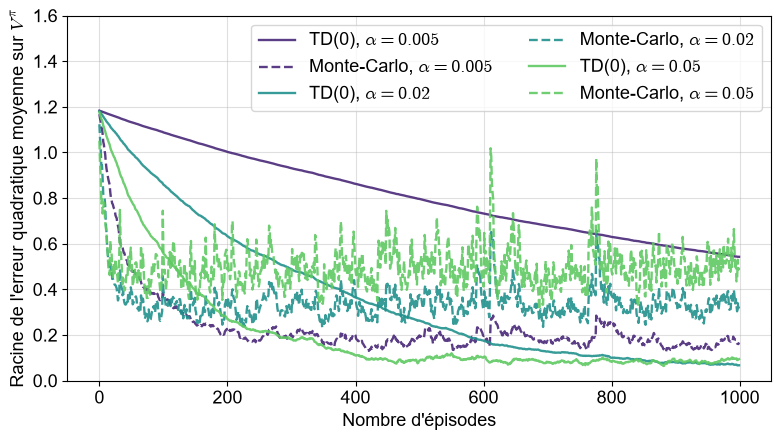

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.6))

for alpha, coul in zip([0.005, 0.02, 0.05], [VIOLET, SARCELLE, VERT]):
    c_td = np.mean([td0(env, pi_alea, 1000, alpha=alpha, graine=g,
                        reference=V_alea)[1] for g in range(10)], axis=0)
    c_mc = np.mean([mc_constant(env, pi_alea, 1000, alpha=alpha, graine=g,
                                reference=V_alea)[1] for g in range(10)], axis=0)
    ax.plot(c_td, color=coul, linewidth=1.7, alpha=0.9,
            label=f"TD(0), $\\alpha = {alpha}$")
    ax.plot(c_mc, color=coul, linewidth=1.7, alpha=0.9, linestyle='--',
            label=f"Monte-Carlo, $\\alpha = {alpha}$")
ax.set_xlabel("Nombre d'épisodes")
ax.set_ylabel("Racine de l'erreur quadratique moyenne sur $V^\\pi$")
ax.set_ylim(0, 1.6)
ax.grid(alpha=0.4, zorder=0)
ax.legend(ncol=2)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap16_MCvsTD')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.4 : SARSA</h3>

In [9]:
def eps_gloutonne(Q, s, actions, epsilon, rng):
    """Action epsilon-gloutonne dans l'état s."""
    if rng.random() < epsilon:
        return actions[rng.integers(len(actions))]
    return max(Q[s], key=Q[s].get)

def sarsa(env, n_episodes, alpha=0.1, gamma=1.0, epsilon=0.1, graine=42):
    """Sur politique : la cible utilise l'action réellement choisie ensuite."""
    rng = np.random.default_rng(graine)
    Q = {s: {a: 0.0 for a in env.ACTIONS}
         for s in env.etats if s not in env.terminaux}
    retours = []
    for _ in range(n_episodes):
        s = env.depart
        a = eps_gloutonne(Q, s, env.ACTIONS, epsilon, rng)
        total = 0.0
        while True:
            s2, r, fin = env.pas(s, a, rng)
            total += r
            if fin:
                Q[s][a] += alpha * (r - Q[s][a])
                break
            a2 = eps_gloutonne(Q, s2, env.ACTIONS, epsilon, rng)
            Q[s][a] += alpha * (r + gamma * Q[s2][a2] - Q[s][a])
            s, a = s2, a2
        retours.append(total)
    return Q, {s: max(Q[s], key=Q[s].get) for s in Q}, retours

Q_s, pi_s, ret_s = sarsa(env, 20000)
print(f"SARSA : {sum(pi_s[s] == pi_opt[s] for s in pi_opt)} / {len(pi_opt)} "
      f"actions optimales, retour moyen des 1000 derniers épisodes "
      f"= {np.mean(ret_s[-1000:]):.3f}")

SARSA : 9 / 9 actions optimales, retour moyen des 1000 derniers épisodes = 0.698


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.5 : Q-learning</h3>

In [10]:
def q_learning(env, n_episodes, alpha=0.1, gamma=1.0, epsilon=0.1, graine=42):
    """Hors politique : la cible utilise la meilleure action, pas celle choisie."""
    rng = np.random.default_rng(graine)
    Q = {s: {a: 0.0 for a in env.ACTIONS}
         for s in env.etats if s not in env.terminaux}
    retours = []
    for _ in range(n_episodes):
        s = env.depart
        total = 0.0
        while True:
            a = eps_gloutonne(Q, s, env.ACTIONS, epsilon, rng)
            s2, r, fin = env.pas(s, a, rng)
            total += r
            cible = r if fin else r + gamma * max(Q[s2].values())
            Q[s][a] += alpha * (cible - Q[s][a])
            s = s2
            if fin:
                break
        retours.append(total)
    return Q, {s: max(Q[s], key=Q[s].get) for s in Q}, retours

Q_q, pi_q, ret_q = q_learning(env, 20000)
print(f"Q-learning : {sum(pi_q[s] == pi_opt[s] for s in pi_opt)} / {len(pi_opt)} "
      f"actions optimales, retour moyen des 1000 derniers épisodes "
      f"= {np.mean(ret_q[-1000:]):.3f}")

Q-learning : 8 / 9 actions optimales, retour moyen des 1000 derniers épisodes = 0.669


<h3><span style="font-size: 30px">&#127924;</span> Figure : Politiques apprises sur le monde en grille</h3>

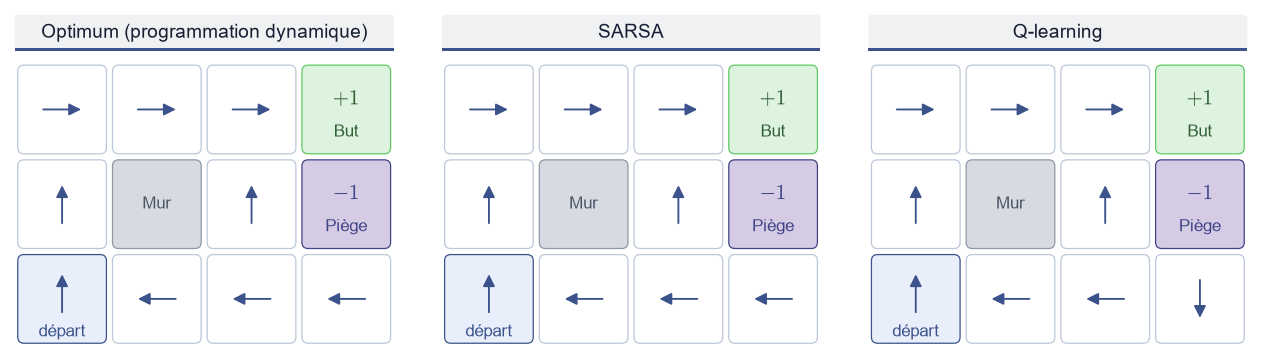

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

dessiner_grille(axes[0], env, politique=pi_opt, titre="Optimum (programmation dynamique)")
dessiner_grille(axes[1], env, politique=pi_s, titre="SARSA")
dessiner_grille(axes[2], env, politique=pi_q, titre="Q-learning")
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap16_GrillePolitiques')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.6 : La marche au bord de la falaise</h3>

In [12]:
class Falaise:
    """Grille 4 x 12. Départ en bas à gauche, but en bas à droite, falaise
    entre les deux. Chaque pas coûte 1, tomber coûte 100 et ramène au départ."""

    ACTIONS = ['haut', 'bas', 'gauche', 'droite']
    PAS = {'haut': (-1, 0), 'bas': (1, 0), 'gauche': (0, -1), 'droite': (0, 1)}

    def __init__(self):
        self.n_lignes, self.n_colonnes = 4, 12
        self.depart = (3, 0)
        self.but = (3, 11)
        self.falaise = {(3, j) for j in range(1, 11)}
        self.terminaux = {self.but: 0.0}
        self.etats = [(i, j) for i in range(4) for j in range(12)]

    def pas(self, s, a, rng=None):
        di, dj = self.PAS[a]
        s2 = (min(max(s[0] + di, 0), self.n_lignes - 1),
              min(max(s[1] + dj, 0), self.n_colonnes - 1))
        if s2 in self.falaise:
            return self.depart, -100.0, False
        return s2, -1.0, s2 == self.but

falaise = Falaise()
print("États :", len(falaise.etats), "dont", len(falaise.falaise), "cases de falaise")
print("Chemin optimal : 13 pas, pour un retour de -13")

États : 48 dont 10 cases de falaise
Chemin optimal : 13 pas, pour un retour de -13


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.7 : SARSA et Q-learning sur la falaise</h3>

In [13]:
Q_fs, pi_fs, ret_fs = sarsa(falaise, 3000, alpha=0.1, epsilon=0.1)
Q_fq, pi_fq, ret_fq = q_learning(falaise, 3000, alpha=0.1, epsilon=0.1)

def chemin_glouton(env, pi, max_pas=60):
    """Suit la politique gloutonne depuis le départ."""
    s, trajet = env.depart, [env.depart]
    for _ in range(max_pas):
        s, r, fin = env.pas(s, pi[s])
        trajet.append(s)
        if fin:
            break
    return trajet

# Calculs
resultats = []

for nom, pi, retours in [
    ("SARSA", pi_fs, ret_fs),
    ("Q-learning", pi_fq, ret_fq)
]:
    chemin = chemin_glouton(falaise, pi)
    retour_moyen = np.mean(retours[-100:])
    n_pas = len(chemin) - 1
    lignes = sorted({i for i, j in chemin})
    resultats.append((nom, retour_moyen, n_pas, lignes))

# --- Affichage ---
L = 70
print("=" * L)
print("Chemins gloutons après 3000 épisodes")
print("=" * L)
print(f"{'Algorithme':<16}{'Retour moyen':>20}{'Chemin (pas)':>16}{'Lignes visitées':>18}")
print("-" * L)

for nom, retour, n_pas, lignes in resultats:
    print(f"{nom:<16}{retour:>20.1f}{n_pas:>16}{str(lignes):>18}")

print("=" * L)

Chemins gloutons après 3000 épisodes
Algorithme              Retour moyen    Chemin (pas)   Lignes visitées
----------------------------------------------------------------------
SARSA                          -21.2              15         [1, 2, 3]
Q-learning                     -65.0              13            [2, 3]


<h3><span style="font-size: 30px">&#127924;</span> Figure : Les deux politiques apprises sur la falaise</h3>

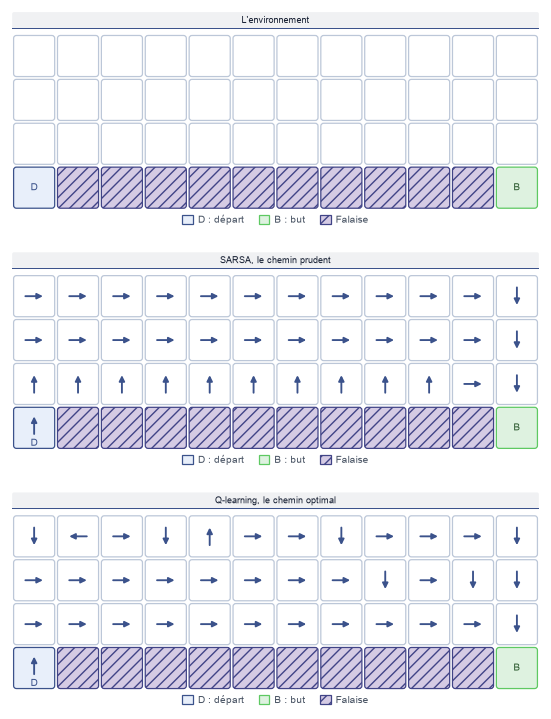

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7.4))

dessiner_grille(axes[0], falaise, titre="L'environnement", taille=13)
dessiner_grille(axes[1], falaise, politique=pi_fs, titre="SARSA, le chemin prudent", taille=13)
dessiner_grille(axes[2], falaise, politique=pi_fq, titre="Q-learning, le chemin optimal", taille=13)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap16_FalaisePolitiques')

plt.show()

<h3><span style="font-size: 30px">&#127924;</span> Figure : Retour par épisode sur la falaise</h3>

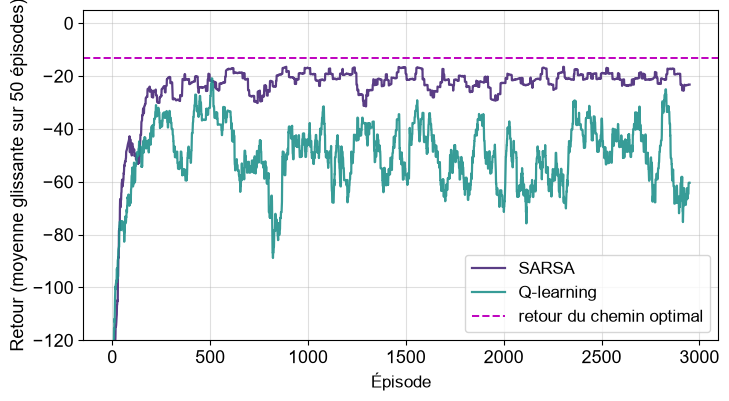

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

ax.plot(lisser(ret_fs), color=VIOLET, linewidth=1.6, alpha=0.9, label='SARSA')
ax.plot(lisser(ret_fq), color=SARCELLE, linewidth=1.6, alpha=0.9, label='Q-learning')
ax.axhline(-13, color=MAGENTA, linestyle='--', linewidth=1.4,
           label='retour du chemin optimal')
ax.set_xlabel("Épisode", fontsize=12)
ax.set_ylabel("Retour (moyenne glissante sur 50 épisodes)")
ax.set_ylim(-120, 5)
ax.grid(alpha=0.4, zorder=0)
ax.legend(fontsize=12, loc='lower right')
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap16_FalaiseRetours')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.8 : SARSA espéré</h3>

In [16]:
def sarsa_espere(env, n_episodes, alpha=0.1, gamma=1.0, epsilon=0.1, graine=42):
    """La cible remplace Q(s', a') par son espérance sous la politique."""
    rng = np.random.default_rng(graine)
    Q = {s: {a: 0.0 for a in env.ACTIONS}
         for s in env.etats if s not in env.terminaux}
    n_a = len(env.ACTIONS)
    retours = []
    for _ in range(n_episodes):
        s, total = env.depart, 0.0
        while True:
            a = eps_gloutonne(Q, s, env.ACTIONS, epsilon, rng)
            s2, r, fin = env.pas(s, a, rng)
            total += r
            if fin:
                cible = r
            else:
                meilleure = max(Q[s2], key=Q[s2].get)
                esperance = sum((1 - epsilon + epsilon / n_a if x == meilleure
                                 else epsilon / n_a) * Q[s2][x] for x in env.ACTIONS)
                cible = r + gamma * esperance
            Q[s][a] += alpha * (cible - Q[s][a])
            s = s2
            if fin:
                break
        retours.append(total)
    return Q, {s: max(Q[s], key=Q[s].get) for s in Q}, retours

# Retour moyen sur l'ensemble des épisodes, pour quatre pas d'apprentissage
alphas = [0.1, 0.3, 0.5, 0.9]
algorithmes = [
    ("SARSA", sarsa),
    ("SARSA espéré", sarsa_espere),
    ("Q-learning", q_learning)
]

courbes_alpha = {}
for nom, algo in algorithmes:
    courbes_alpha[nom] = [
        np.mean([
            np.mean(algo(falaise, 1000, alpha=alpha,
                         epsilon=0.1, graine=g)[2])
            for g in range(5)
        ])
        for alpha in alphas
    ]

# --- Affichage ---
L = 67
print("=" * L)
print(f"{'Algorithme':<15}"
      + "".join(f"{f'α = {a:.1f}':>13}" for a in alphas))
print("-" * L)

for nom, _ in algorithmes:
    print(f"{nom:<15}"
          + "".join(f"{v:>13.1f}" for v in courbes_alpha[nom]))

print("=" * L)

Algorithme           α = 0.1      α = 0.3      α = 0.5      α = 0.9
-------------------------------------------------------------------
SARSA                  -36.8        -30.4        -31.6        -74.9
SARSA espéré           -36.3        -26.3        -24.8        -23.4
Q-learning             -60.4        -56.4        -56.0        -56.5


<h3><span style="font-size: 30px">&#127924;</span> Figure : Sensibilité au pas d'apprentissage</h3>

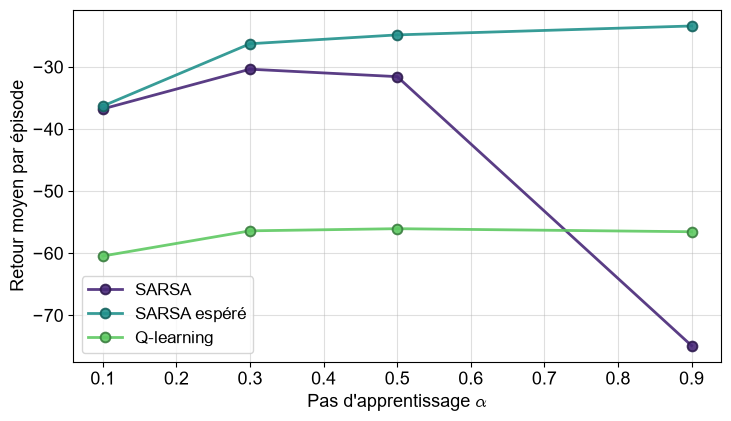

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))

for (nom, vals), coul in zip(courbes_alpha.items(), [VIOLET, SARCELLE, VERT]):
    ax.plot(alphas, vals, marker='o', markersize=7, color=coul, linewidth=2,
            markeredgecolor=BORD.get(coul, '0.2'), markeredgewidth=1.4,
            alpha=0.9, label=nom, zorder=3)
ax.set_xlabel("Pas d'apprentissage $\\alpha$")
ax.set_ylabel("Retour moyen par épisode")
ax.grid(alpha=0.4, zorder=0)
ax.legend(fontsize=12)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap16_Alpha')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.9 : Biais de maximisation et double Q-learning</h3>

In [18]:
class BiaisMaximisation:
    """Depuis A, « droite » termine avec 0 ; « gauche » mène en B, d'où
    dix actions mènent à un terminal de récompense N(-0.1, 1). Aller à
    gauche est donc mauvais, mais le maximum d'estimations bruitées le
    fait paraître bon."""

    def __init__(self, n_actions=10):
        self.etats = ['A', 'B']
        self.ACTIONS = {'A': ['gauche', 'droite'],
                        'B': [f'b{i}' for i in range(n_actions)]}
        self.depart = 'A'

    def pas(self, s, a, rng):
        if s == 'A':
            return ('B', 0.0, False) if a == 'gauche' else (None, 0.0, True)
        return None, rng.normal(-0.1, 1.0), True

def apprentissage_biais(env, n_episodes, alpha=0.1, epsilon=0.1, graine=42,double=False):
    """Q-learning simple ou double, sur le problème du biais de maximisation."""
    rng = np.random.default_rng(graine)
    Q1 = {s: {a: 0.0 for a in env.ACTIONS[s]} for s in env.etats}
    Q2 = {s: {a: 0.0 for a in env.ACTIONS[s]} for s in env.etats}
    gauches = []
    for _ in range(n_episodes):
        s, pris_gauche = env.depart, False
        while True:
            somme = ({a: Q1[s][a] + Q2[s][a] for a in env.ACTIONS[s]}
                     if double else Q1[s])
            if rng.random() < epsilon:
                a = env.ACTIONS[s][rng.integers(len(env.ACTIONS[s]))]
            else:
                maximum = max(somme.values())
                meilleures = [a for a, v in somme.items() if v == maximum]
                a = meilleures[rng.integers(len(meilleures))]
            if s == 'A' and a == 'gauche':
                pris_gauche = True
            s2, r, fin = env.pas(s, a, rng)
            if double:
                QA, QB = (Q1, Q2) if rng.random() < 0.5 else (Q2, Q1)
                cible = r if fin else r + QB[s2][max(QA[s2], key=QA[s2].get)]
                QA[s][a] += alpha * (cible - QA[s][a])
            else:
                cible = r if fin else r + max(Q1[s2].values())
                Q1[s][a] += alpha * (cible - Q1[s][a])
            if fin:
                break
            s = s2
        gauches.append(pris_gauche)
    return np.array(gauches, dtype=float)

biais = BiaisMaximisation()

g_simple = np.mean([apprentissage_biais(biais, 300, graine=g) for g in range(50)], axis=0)
g_double = np.mean([apprentissage_biais(biais, 300, graine=g, double=True) for g in range(50)], axis=0)

taux_simple = 100 * g_simple[:100].mean()
taux_double = 100 * g_double[:100].mean()
taux_reference = 5.0

resultats = [
    ("Q-learning", taux_simple),
    ("Double Q-learning", taux_double),
    ("Référence epsilon-gloutonne", taux_reference)
]

# --- Affichage ---
L = 58
print("=" * L)
print("Choix « gauche » (←) sur les 100 premiers épisodes")
print("=" * L)
print(f"{'Méthode':<34}{'Fréquence (%)':>24}")
print("-" * L)

for nom, taux in resultats:
    print(f"{nom:<34}{taux:>24.1f}")

print("=" * L)

Choix « gauche » (←) sur les 100 premiers épisodes
Méthode                                      Fréquence (%)
----------------------------------------------------------
Q-learning                                            68.2
Double Q-learning                                     20.2
Référence epsilon-gloutonne                            5.0


<h3><span style="font-size: 30px">&#127924;</span> Figure : Biais de maximisation</h3>

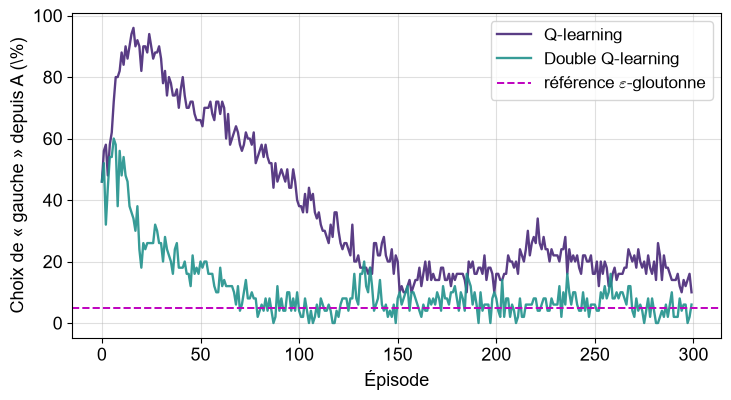

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

ax.plot(100 * g_simple, color=VIOLET, linewidth=1.7, alpha=0.9, label='Q-learning')
ax.plot(100 * g_double, color=SARCELLE, linewidth=1.7, alpha=0.9,
        label='Double Q-learning')
ax.axhline(5, color=MAGENTA, linestyle='--', linewidth=1.4,
           label='référence $\\varepsilon$-gloutonne')
ax.set_xlabel("Épisode")
ax.set_ylabel("Choix de « gauche » depuis A (\\%)")
ax.grid(alpha=0.4, zorder=0)
ax.legend(fontsize=12)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap16_BiaisMax')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.10 : TD(λ) et traces d'éligibilité</h3>

In [20]:
def td_lambda(env, pi, n_episodes, alpha=0.02, lam=0.6, gamma=1.0,
              graine=42, reference=None):
    """Chaque erreur TD est répercutée sur tous les états récemment visités,
    avec un poids décroissant porté par la trace d'éligibilité."""
    if reference is None:
        raise ValueError("Une valeur de référence doit être fournie.")
        
    rng = np.random.default_rng(graine)
    V = {s: 0.0 for s in env.etats}
    interieurs = [s for s in env.etats if s not in env.terminaux]
    for _ in range(n_episodes):
        E = {s: 0.0 for s in env.etats}
        s = env.depart
        while s not in env.terminaux:
            a = rng.choice(env.ACTIONS, p=[pi[s][x] for x in env.ACTIONS])
            s2, r, fin = env.pas(s, a, rng)
            delta = r + gamma * (0.0 if fin else V[s2]) - V[s]
            E[s] += 1.0
            for u in interieurs:
                if E[u] != 0.0:
                    V[u] += alpha * delta * E[u]
                    E[u] *= gamma * lam
            s = s2
    return np.sqrt(np.mean([(V[u] - reference[u]) ** 2 for u in interieurs]))

lambdas = [0.0, 0.3, 0.6, 0.9, 1.0]
alphas = [0.01, 0.02, 0.05]
courbes_lambda = {}

for alpha in alphas:
    courbes_lambda[alpha] = [
        np.mean([
            td_lambda(
                env, pi_alea, 500, alpha=alpha,
                lam=lam, graine=g, reference=V_alea
            )
            for g in range(5)
        ])
        for lam in lambdas
    ]

# --- Affichage ---
L = 75
print("=" * L)
print("Racine de l'erreur quadratique moyenne après 500 épisodes (5 exécutions)")
print("=" * L)
print(f"{'Alpha':<10}"
      + "".join(f"{f'λ = {lam:.2f}':>13}" for lam in lambdas))
print("-" * L)

for alpha in alphas:
    print(f"{alpha:<10.2f}"
          + "".join(f"{v:>13.3f}" for v in courbes_lambda[alpha]))

print("=" * L)

Racine de l'erreur quadratique moyenne après 500 épisodes (5 exécutions)
Alpha          λ = 0.00     λ = 0.30     λ = 0.60     λ = 0.90     λ = 1.00
---------------------------------------------------------------------------
0.01              0.548        0.405        0.202        0.111        0.243
0.02              0.262        0.149        0.088        0.164        0.324
0.05              0.093        0.108        0.138        0.238        0.440


<h3><span style="font-size: 30px">&#127924;</span> Figure : Effet du paramètre $\lambda$</h3>

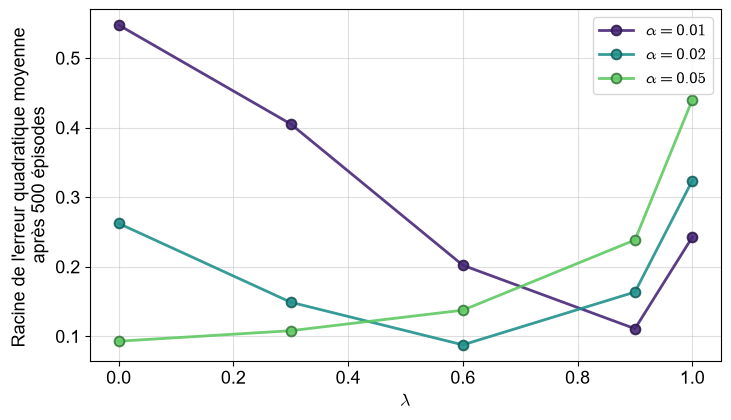

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))

for (alpha, vals), coul in zip(courbes_lambda.items(), [VIOLET, SARCELLE, VERT]):
    ax.plot(lambdas, vals, marker='o', markersize=7, color=coul, linewidth=2,
            markeredgecolor=BORD.get(coul, '0.2'), markeredgewidth=1.4,
            alpha=0.9, label=f"$\\alpha = {alpha}$", zorder=3)
ax.set_xlabel("$\\lambda$")
ax.set_ylabel("Racine de l'erreur quadratique moyenne \naprès 500 épisodes")
ax.grid(alpha=0.4, zorder=0)
ax.legend(fontsize=12)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap16_Lambda')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 16.11 : Réglage du taux d'exploration</h3>

In [22]:
def q_learning_calendrier(env, n_episodes, calendrier, alpha=0.1, gamma=1.0,
                          graine=42):
    """Q-learning dont le taux d'exploration suit un calendrier."""
    rng = np.random.default_rng(graine)
    Q = {s: {a: 0.0 for a in env.ACTIONS}
         for s in env.etats if s not in env.terminaux}
    retours = []
    for k in range(n_episodes):
        epsilon = calendrier(k)
        s, total = env.depart, 0.0
        while True:
            a = eps_gloutonne(Q, s, env.ACTIONS, epsilon, rng)
            s2, r, fin = env.pas(s, a, rng)
            total += r
            cible = r if fin else r + gamma * max(Q[s2].values())
            Q[s][a] += alpha * (cible - Q[s][a])
            s = s2
            if fin:
                break
        retours.append(total)
    return {s: max(Q[s], key=Q[s].get) for s in Q}, retours

calendriers = {
    "Constant, ε = 0.01": lambda k: 0.01,
    "Constant, ε = 0.10": lambda k: 0.10,
    "Constant, ε = 0.30": lambda k: 0.30,
    "Décroissant, ε = 0.50 à 0.01":
        lambda k: max(0.01, 0.5 * 0.999 ** k)
}

resultats_calendrier = []

for nom, calendrier in calendriers.items():
    corrects, retours_moyens = [], []

    for g in range(10):
        pi, retours = q_learning_calendrier(env, 5000, calendrier, graine=g)
        corrects.append(sum(pi[s] == pi_opt[s] for s in pi_opt))
        retours_moyens.append(np.mean(retours))

    resultats_calendrier.append((
        nom,
        np.mean(corrects),
        np.mean(retours_moyens)
    ))

# --- Affichage ---
L = 72
print("=" * L)
print("Effet du calendrier d'exploration (10 exécutions)")
print("=" * L)
print(f"{'Calendrier':<34}"
      f"{'Actions identiques':>22}"
      f"{'Retour moyen':>16}")
print("-" * L)

for nom, corrects, retour in resultats_calendrier:
    print(f"{nom:<34}"
          f"{f'{corrects:.1f} / 9':>22}"
          f"{retour:>16.3f}")

print("=" * L)

Effet du calendrier d'exploration (10 exécutions)
Calendrier                            Actions identiques    Retour moyen
------------------------------------------------------------------------
Constant, ε = 0.01                               7.3 / 9           0.675
Constant, ε = 0.10                               7.6 / 9           0.661
Constant, ε = 0.30                               8.2 / 9           0.514
Décroissant, ε = 0.50 à 0.01                     7.8 / 9           0.659


<hr style='border-top:4px solid #1F77B4;'>